# Breast Cancer Wisconsin (Diagnostic) Dataset
## Exploratory Data Analysis, Feature Engineering, Splitting and Logistic Regression

### Dataset Description
The Breast Cancer Wisconsin (Diagnostic) dataset contains features computed from digitized images of fine needle aspirates (FNA) of breast masses.

The objective is to predict whether a tumor is:

- Malignant (M)
- Benign (B)

### Problem Type
Binary Classification

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.decomposition import PCA

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.shape

(569, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


## Missing Values Analysis

In [6]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
df = df.drop(columns=["Unnamed: 32"])

## Duplicate Analysis

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Class Distribution

This section examines whether the dataset is balanced or imbalanced.

In [9]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [10]:
df["diagnosis"].value_counts(normalize=True)*100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

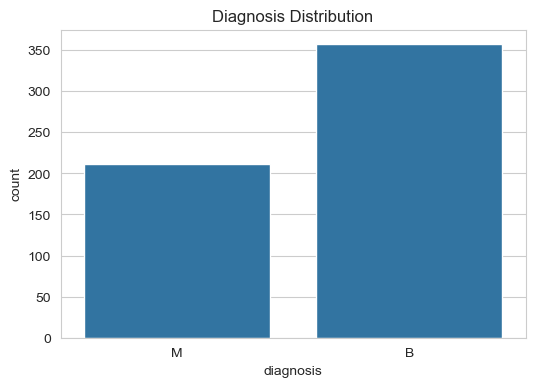

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Diagnosis Distribution")
plt.show()

The dataset is moderately balanced with more benign cases than malignant cases.
Stratified sampling will therefore be used during train-test splitting.

# Histograms

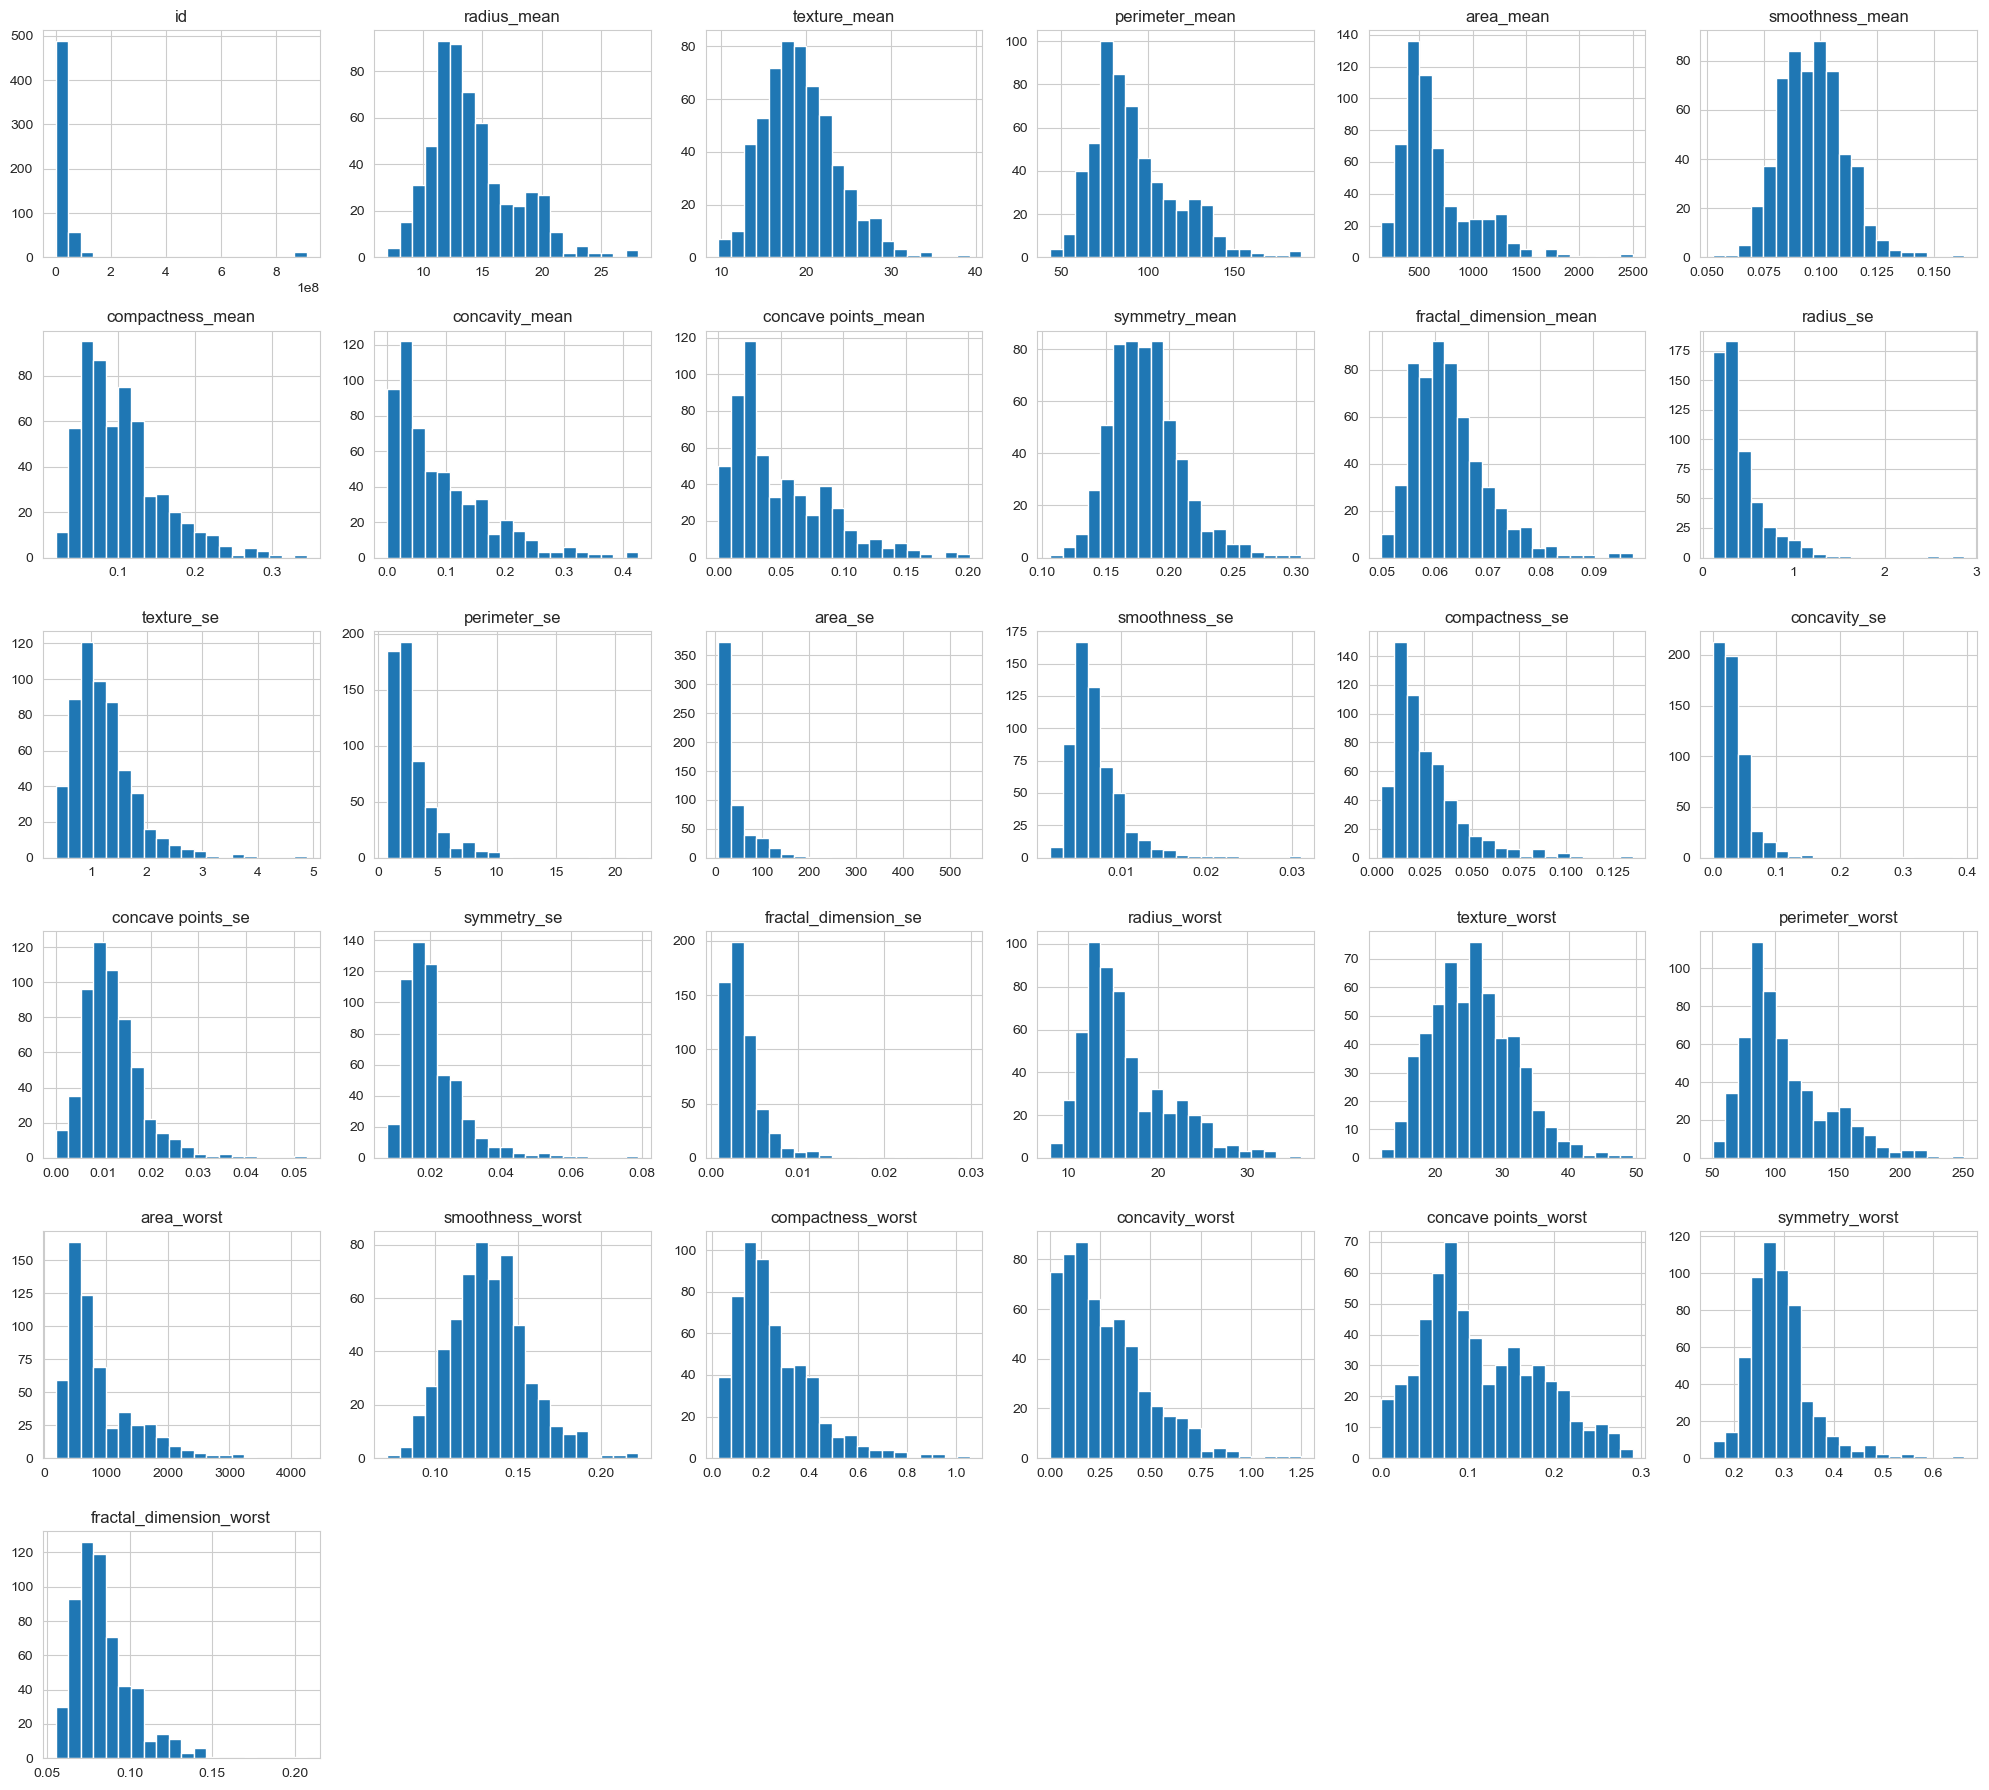

In [12]:
df.hist(
    figsize=(20,18),
    bins=20
)

plt.tight_layout()
plt.show()

# Bivariate Analysis

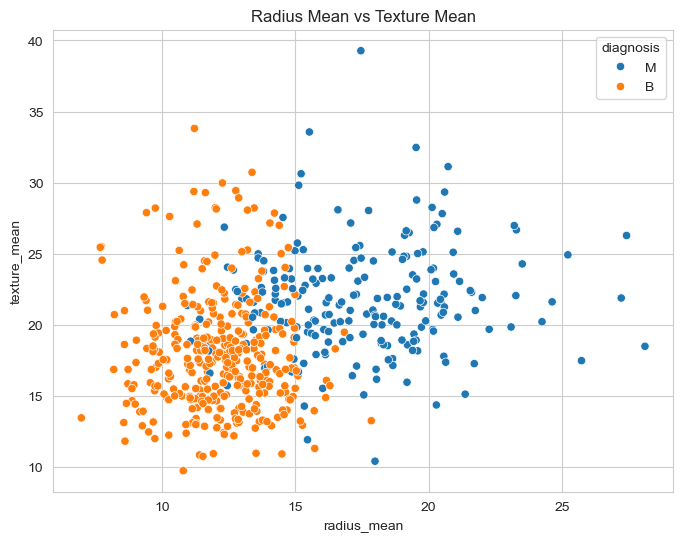

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="radius_mean",
    y="texture_mean",
    hue="diagnosis"
)

plt.title(
    "Radius Mean vs Texture Mean"
)

plt.show()

## Area vs Parameter

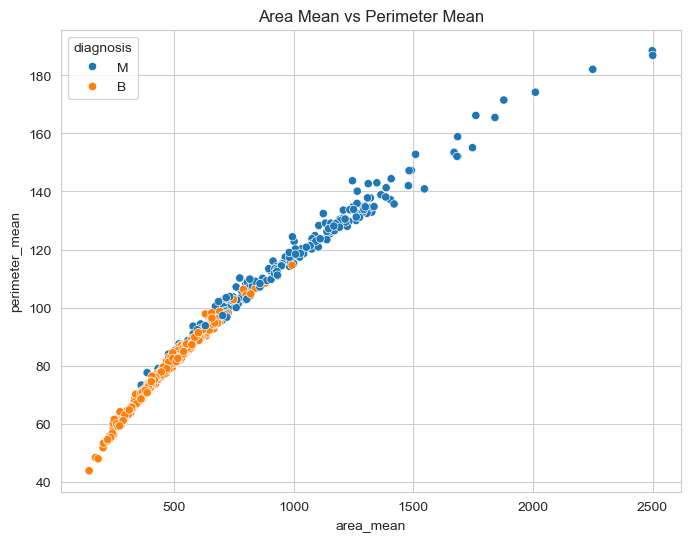

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="area_mean",
    y="perimeter_mean",
    hue="diagnosis"
)

plt.title(
    "Area Mean vs Perimeter Mean"
)

plt.show()

## Radius vs Area

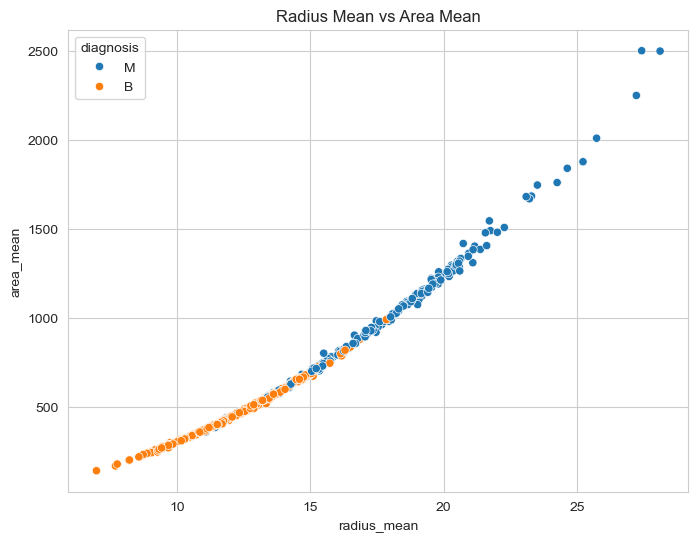

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="radius_mean",
    y="area_mean",
    hue="diagnosis"
)

plt.title(
    "Radius Mean vs Area Mean"
)

plt.show()

# Boxplots

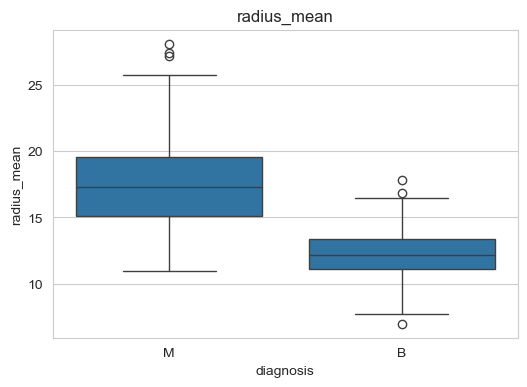

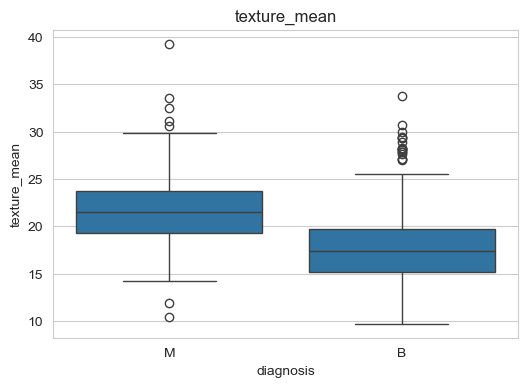

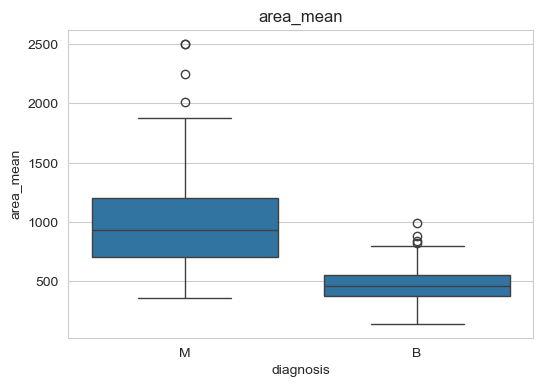

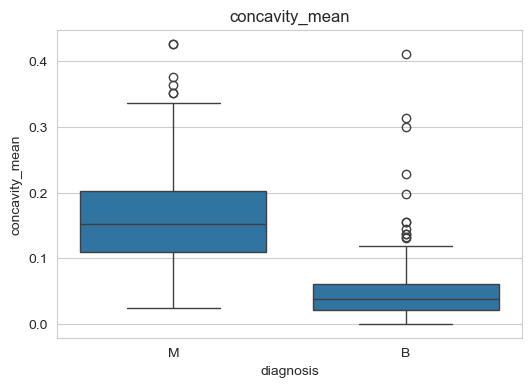

In [16]:
features = [
    "radius_mean",
    "texture_mean",
    "area_mean",
    "concavity_mean"
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="diagnosis",
        y=col,
        data=df
    )

    plt.title(col)

    plt.show()

# Correlation Analysis

In [17]:
corr = df.drop(
    columns=["id"]
).corr(numeric_only=True)

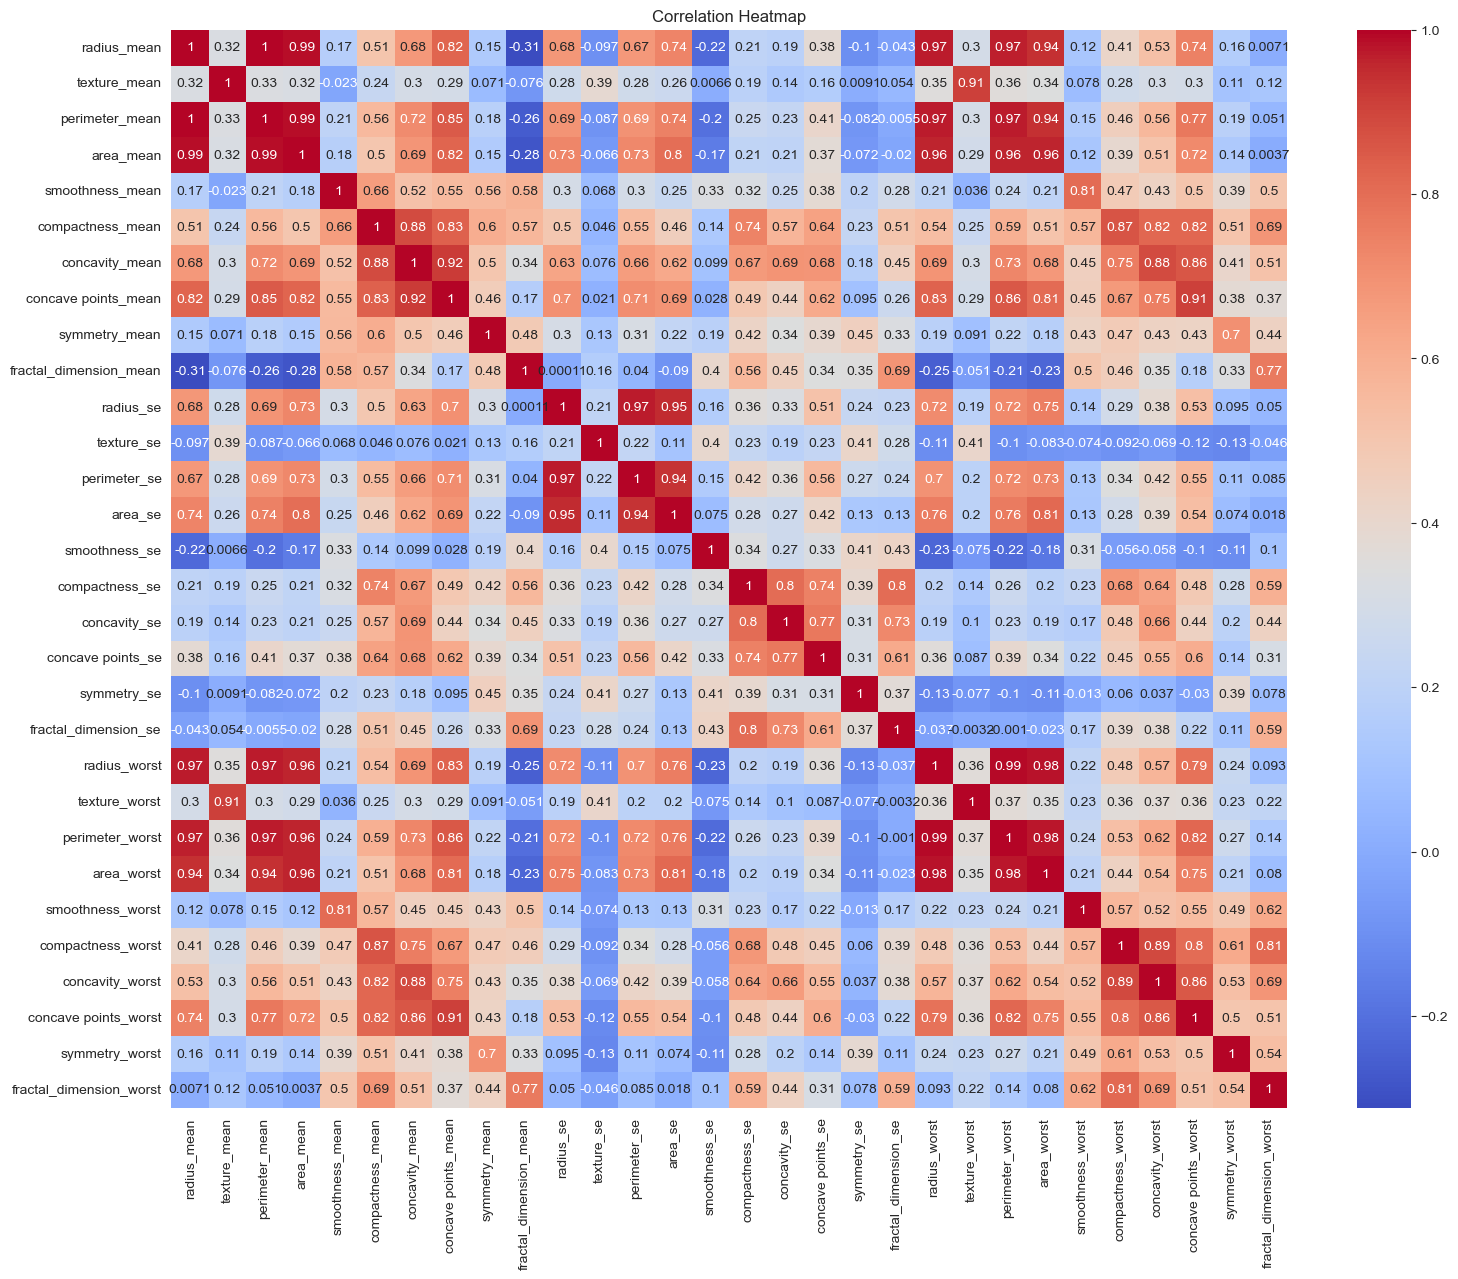

In [18]:
plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    cmap="coolwarm", annot=True
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

## Strongest Correlations

In [19]:
corr_matrix = corr.abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

upper.stack().sort_values(
    ascending=False
).head(20)

radius_mean      perimeter_mean         0.997855
radius_worst     perimeter_worst        0.993708
radius_mean      area_mean              0.987357
perimeter_mean   area_mean              0.986507
radius_worst     area_worst             0.984015
perimeter_worst  area_worst             0.977578
radius_se        perimeter_se           0.972794
perimeter_mean   perimeter_worst        0.970387
radius_mean      radius_worst           0.969539
perimeter_mean   radius_worst           0.969476
radius_mean      perimeter_worst        0.965137
area_mean        radius_worst           0.962746
                 area_worst             0.959213
                 perimeter_worst        0.959120
radius_se        area_se                0.951830
perimeter_mean   area_worst             0.941550
radius_mean      area_worst             0.941082
perimeter_se     area_se                0.937655
concavity_mean   concave points_mean    0.921391
texture_mean     texture_worst          0.912045
dtype: float64

# Outlier Detection

In [20]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

In [21]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

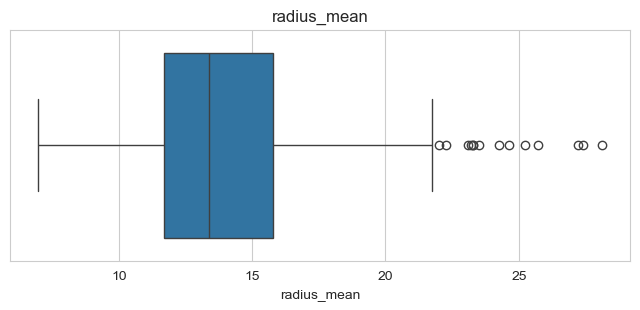

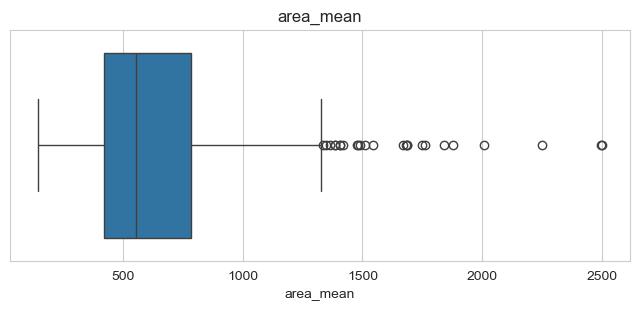

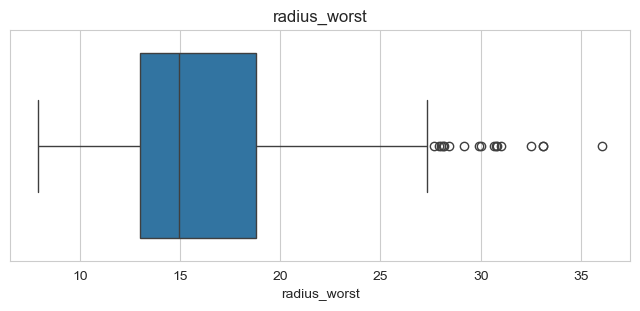

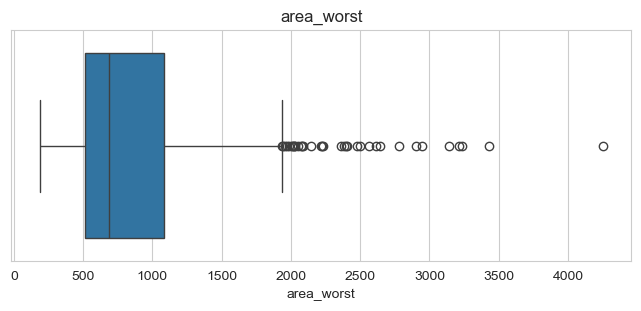

In [22]:
for col in [
    "radius_mean",
    "area_mean",
    "radius_worst",
    "area_worst"
]:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

### Hypotheses

1. Tumors with larger radius are more likely malignant.

2. Larger area values indicate malignant tumors.

3. Greater concavity suggests malignancy.

4. Radius, perimeter and area will be strongest predictors.

# Feature Engineering

In [23]:
df["diagnosis"] = df["diagnosis"].map(
    {
        "B":0,
        "M":1
    }
)

In [24]:
df["radius_texture_interaction"] = (
    df["radius_mean"] *
    df["texture_mean"]
)

In [25]:
df["shape_complexity"] = (
    df["concavity_mean"] +
    df["compactness_mean"] +
    df["concave points_mean"]
)/3

In [26]:
df["area_radius_ratio"] = (
    df["area_mean"] /
    df["radius_mean"]
)

In [27]:
# feature matrix
X = df.drop(
    columns=[
        "id",
        "diagnosis"
    ]
)

y = df["diagnosis"]

In [28]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
#Cross Validation
log_reg = LogisticRegression(
    max_iter=5000
)

In [31]:
cv_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

In [32]:
print(cv_scores)

[0.96703297 0.98901099 0.95604396 0.97802198 0.96703297]


In [33]:
print(
    "Mean Accuracy:",
    cv_scores.mean()
)

Mean Accuracy: 0.9714285714285715


# Logisitic Regression

In [34]:
log_reg.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=5000)

In [35]:
y_pred = log_reg.predict(
    X_test_scaled
)

In [36]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

Accuracy: 0.9736842105263158


In [37]:
print(
    "Recall:",
    recall_score(
        y_test,
        y_pred
    )
)

Recall: 0.9523809523809523


In [38]:
print(
    "Precision:",
    precision_score(
        y_test,
        y_pred
    )
)

Precision: 0.975609756097561


In [39]:
print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred
    )
)

F1 Score: 0.963855421686747


# Classification Report

In [40]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# Confusion Matrix

In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

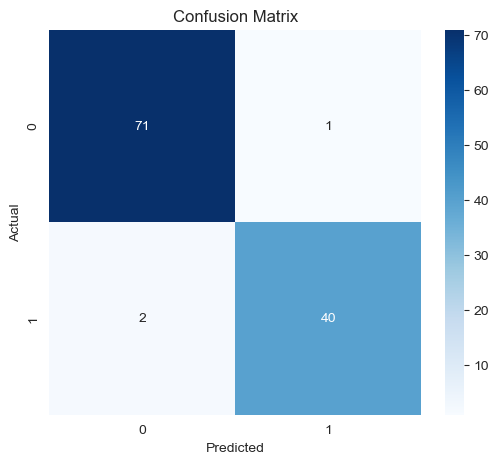

In [42]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.show()

# ROC Curve

In [43]:
y_prob = log_reg.predict_proba(
    X_test_scaled
)[:,1]

In [44]:
fpr,tpr,_ = roc_curve(
    y_test,
    y_prob
)

In [45]:
auc = roc_auc_score(
    y_test,
    y_prob
)

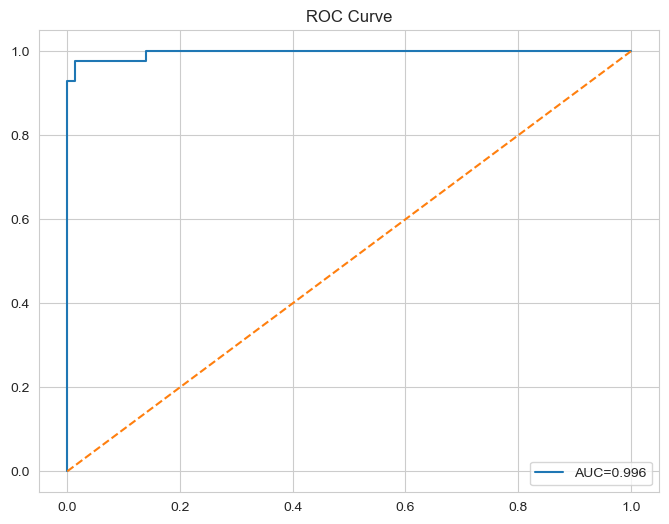

In [46]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.legend()

plt.title(
    "ROC Curve"
)

plt.show()

In [48]:
# PCA Visualizations
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_train_scaled
)

In [49]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["diagnosis"] = y_train.values

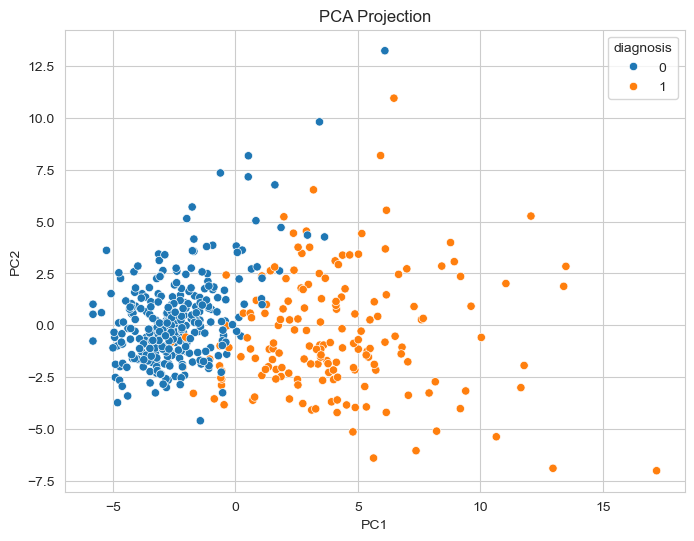

In [50]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="diagnosis"
)

plt.title(
    "PCA Projection"
)

plt.show()